In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from datetime import datetime
from google.colab import drive

drive.mount('/content/drive')
# Load raw (for RFM history) and processed (for merging)
df = pd.read_csv('/content/drive/MyDrive/credit_risk_analysis/data/processed/eda_snapshot.csv')
df_processed = pd.read_csv('/content/drive/MyDrive/credit_risk_analysis/data/processed/processed.csv')

print(f"Raw df shape: {df.shape}")  # Expect (95662, 20)
print(f"Processed df shape: {df_processed.shape}")  # Expect (95662, 29)
print("Raw cols:", df.columns.tolist())

Mounted at /content/drive
Raw df shape: (95662, 20)
Processed df shape: (95662, 20)
Raw cols: ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult', 'TransactionHour', 'TransactionDay', 'TransactionMonth', 'TransactionYear']


In [7]:
# Snapshot date (1 day after max to ensure all Recency >0)
snapshot_date = pd.to_datetime('2019-02-14').tz_localize('UTC') # Assuming UTC, adjust if needed
print(f"Snapshot date: {snapshot_date}")

# Convert TransactionStartTime to datetime before grouping
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])

# RFM per CustomerId
rfm_df = df.groupby('CustomerId').agg({
    'TransactionStartTime': lambda x: (snapshot_date - x.max()).days,  # Recency: days since last txn
    'Value': ['count', 'sum']  # Frequency: count; Monetary: total Value
}).round(4)
rfm_df.columns = ['Recency', 'Frequency', 'Monetary']
rfm_df = rfm_df.reset_index()

print("RFM shape:", rfm_df.shape)  # ~3742 customers
print("\nRFM Summary:\n", rfm_df[['Recency', 'Frequency', 'Monetary']].describe())
print("\nRFM Sample:\n", rfm_df.head(3))

Snapshot date: 2019-02-14 00:00:00+00:00
RFM shape: (3742, 4)

RFM Summary:
            Recency    Frequency      Monetary
count  3742.000000  3742.000000  3.742000e+03
mean     31.127205    25.564404  2.531025e+05
std      27.135672    96.929602  2.715877e+06
min       0.000000     1.000000  5.000000e+01
25%       5.000000     2.000000  6.500000e+03
50%      25.000000     7.000000  3.200000e+04
75%      54.000000    20.000000  1.020600e+05
max      90.000000  4091.000000  1.049000e+08

RFM Sample:
         CustomerId  Recency  Frequency  Monetary
0     CustomerId_1       84          1     10000
1    CustomerId_10       84          1     10000
2  CustomerId_1001       89          5     30400


In [4]:
print(df['TransactionStartTime'].dtype)
print(pd.to_datetime(df['TransactionStartTime']).dtype)

object
datetime64[ns, UTC]


In [8]:
# Scale RFM (KMeans needs normalized feats)
scaler = StandardScaler()
rfm_scaled_arr = scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled_arr, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])
rfm_scaled['CustomerId'] = rfm_df['CustomerId']

# KMeans: 3 clusters, reproducible
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm_scaled['cluster'] = kmeans.fit_predict(rfm_scaled[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']])

# Centroids (raw scale for interpretability)
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=['Recency', 'Frequency', 'Monetary'])
centroids['cluster'] = range(3)
print("Cluster Centroids (Raw):\n", centroids.round(2))

# Cluster sizes
print("\nCluster Sizes:\n", rfm_scaled['cluster'].value_counts().sort_index())

Cluster Centroids (Raw):
    Recency  Frequency     Monetary  cluster
0    12.44      34.61    223561.70        0
1    22.75    1104.50  74876587.00        1
2    61.66       7.75     91117.81        2

Cluster Sizes:
 cluster
0    2318
1       4
2    1420
Name: count, dtype: int64


In [11]:
# Identify high-risk: Lowest engagement (max Recency, min Freq+Mon)
engagement_score = centroids['Frequency'] + centroids['Monetary'] - centroids['Recency']  # High score = engaged
risky_cluster = engagement_score.idxmin()
print(f"High-risk cluster: {risky_cluster} (Rec={centroids.loc[risky_cluster, 'Recency']:.1f}d, Freq={centroids.loc[risky_cluster, 'Frequency']:.0f}, Mon=${centroids.loc[risky_cluster, 'Monetary']:.0f})")

# Binary target
rfm_scaled['is_high_risk'] = (rfm_scaled['cluster'] == risky_cluster).astype(int)

# Dedup processed to customer-level (using your df_processed as raw base)
df_processed_unique = df_processed.drop_duplicates(subset=['CustomerId'])
print(f"Dedup processed shape: {df_processed_unique.shape}")  # ~3742

# Merge
df_final = df_processed_unique.merge(rfm_scaled[['CustomerId', 'is_high_risk']], on='CustomerId', how='left')
print(f"Final shape w/ target: {df_final.shape}")
print("\nTarget Balance (%):\n", (df_final['is_high_risk'].value_counts(normalize=True) * 100).round(2))

# Quick calc Value_mean per customer for sample (ties to Monetary insight)
df_final['Value_mean'] = df_final.groupby('CustomerId')['Value'].transform('mean')  # If 'Value' in raw

# Sample w/ target (use Value_mean instead of scaled)
print("\nSample w/ target:\n", df_final[['CustomerId', 'is_high_risk', 'Value_mean']].head(3))

# Save
df_final.to_csv('/content/drive/MyDrive/credit_risk_analysis/data/processed/xente_final_with_target.csv', index=False)
print("Final saved for modeling!")

High-risk cluster: 2 (Rec=61.7d, Freq=8, Mon=$91118)
Dedup processed shape: (3742, 20)
Final shape w/ target: (3742, 21)

Target Balance (%):
 is_high_risk
0    62.05
1    37.95
Name: proportion, dtype: float64

Sample w/ target:
         CustomerId  is_high_risk  Value_mean
0  CustomerId_4406             0      1000.0
1  CustomerId_4683             1       500.0
2   CustomerId_988             0     21800.0
Final saved for modeling!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


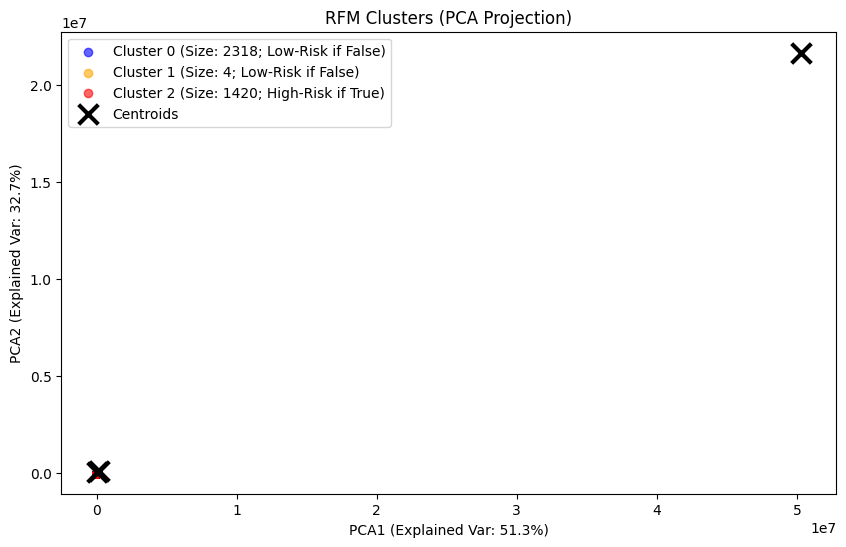

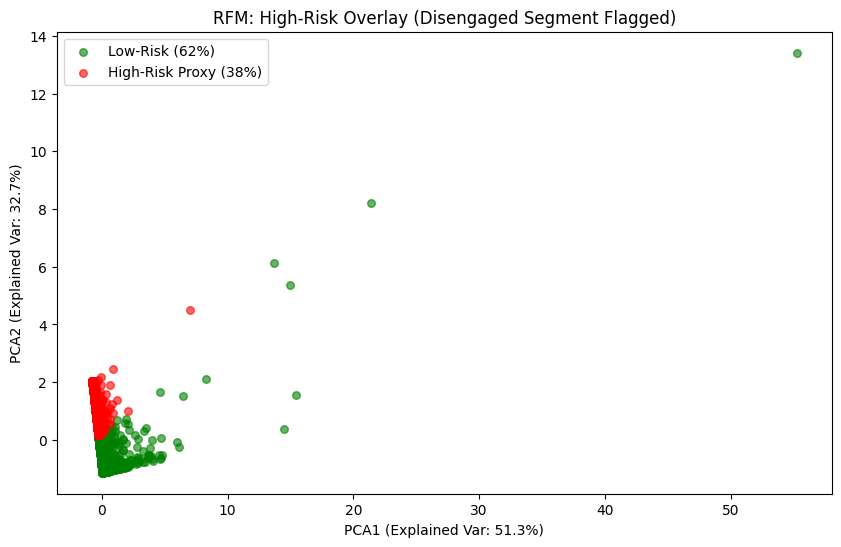

In [12]:
# PCA for 2D viz
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled[['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']])

plt.figure(figsize=(10, 6))
colors = ['blue', 'orange', 'red']  # 0=blue (loyal), 1=orange (whales), 2=red (high-risk)
for i in range(3):
    mask = rfm_scaled['cluster'] == i
    plt.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1], c=colors[i], label=f'Cluster {i} (Size: {mask.sum()}; {"High-Risk" if i==risky_cluster else "Low-Risk"} if {i==risky_cluster})', alpha=0.6)
cent_pca = pca.transform(scaler.inverse_transform(kmeans.cluster_centers_))
plt.scatter(cent_pca[:, 0], cent_pca[:, 1], marker='x', s=200, c='black', linewidth=3, label='Centroids')
plt.title('RFM Clusters (PCA Projection)')
plt.xlabel(f'PCA1 (Explained Var: {pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PCA2 (Explained Var: {pca.explained_variance_ratio_[1]:.1%})')
plt.legend()
plt.savefig('/content/rfm_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# High-risk overlay (binary view)
high_mask = rfm_scaled['is_high_risk'] == 1
plt.figure(figsize=(10, 6))
plt.scatter(rfm_pca[~high_mask, 0], rfm_pca[~high_mask, 1], c='green', label='Low-Risk (62%)', alpha=0.6, s=30)
plt.scatter(rfm_pca[high_mask, 0], rfm_pca[high_mask, 1], c='red', label='High-Risk Proxy (38%)', alpha=0.6, s=30)
plt.title('RFM: High-Risk Overlay (Disengaged Segment Flagged)')
plt.xlabel(f'PCA1 (Explained Var: {pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PCA2 (Explained Var: {pca.explained_variance_ratio_[1]:.1%})')
plt.legend()
plt.savefig('/content/high_risk_overlay.png', dpi=150, bbox_inches='tight')
plt.show()